In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [21]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0
16999,-124.35,40.54,52.0,1820.0,300.0,806.0,270.0,3.0147,94600.0


In [8]:
display(df.describe())
df.info()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [5]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
  print("No missing values found in the dataset.")

,0


No missing values found in the dataset.


<Figure size 1500x1500 with 0 Axes>

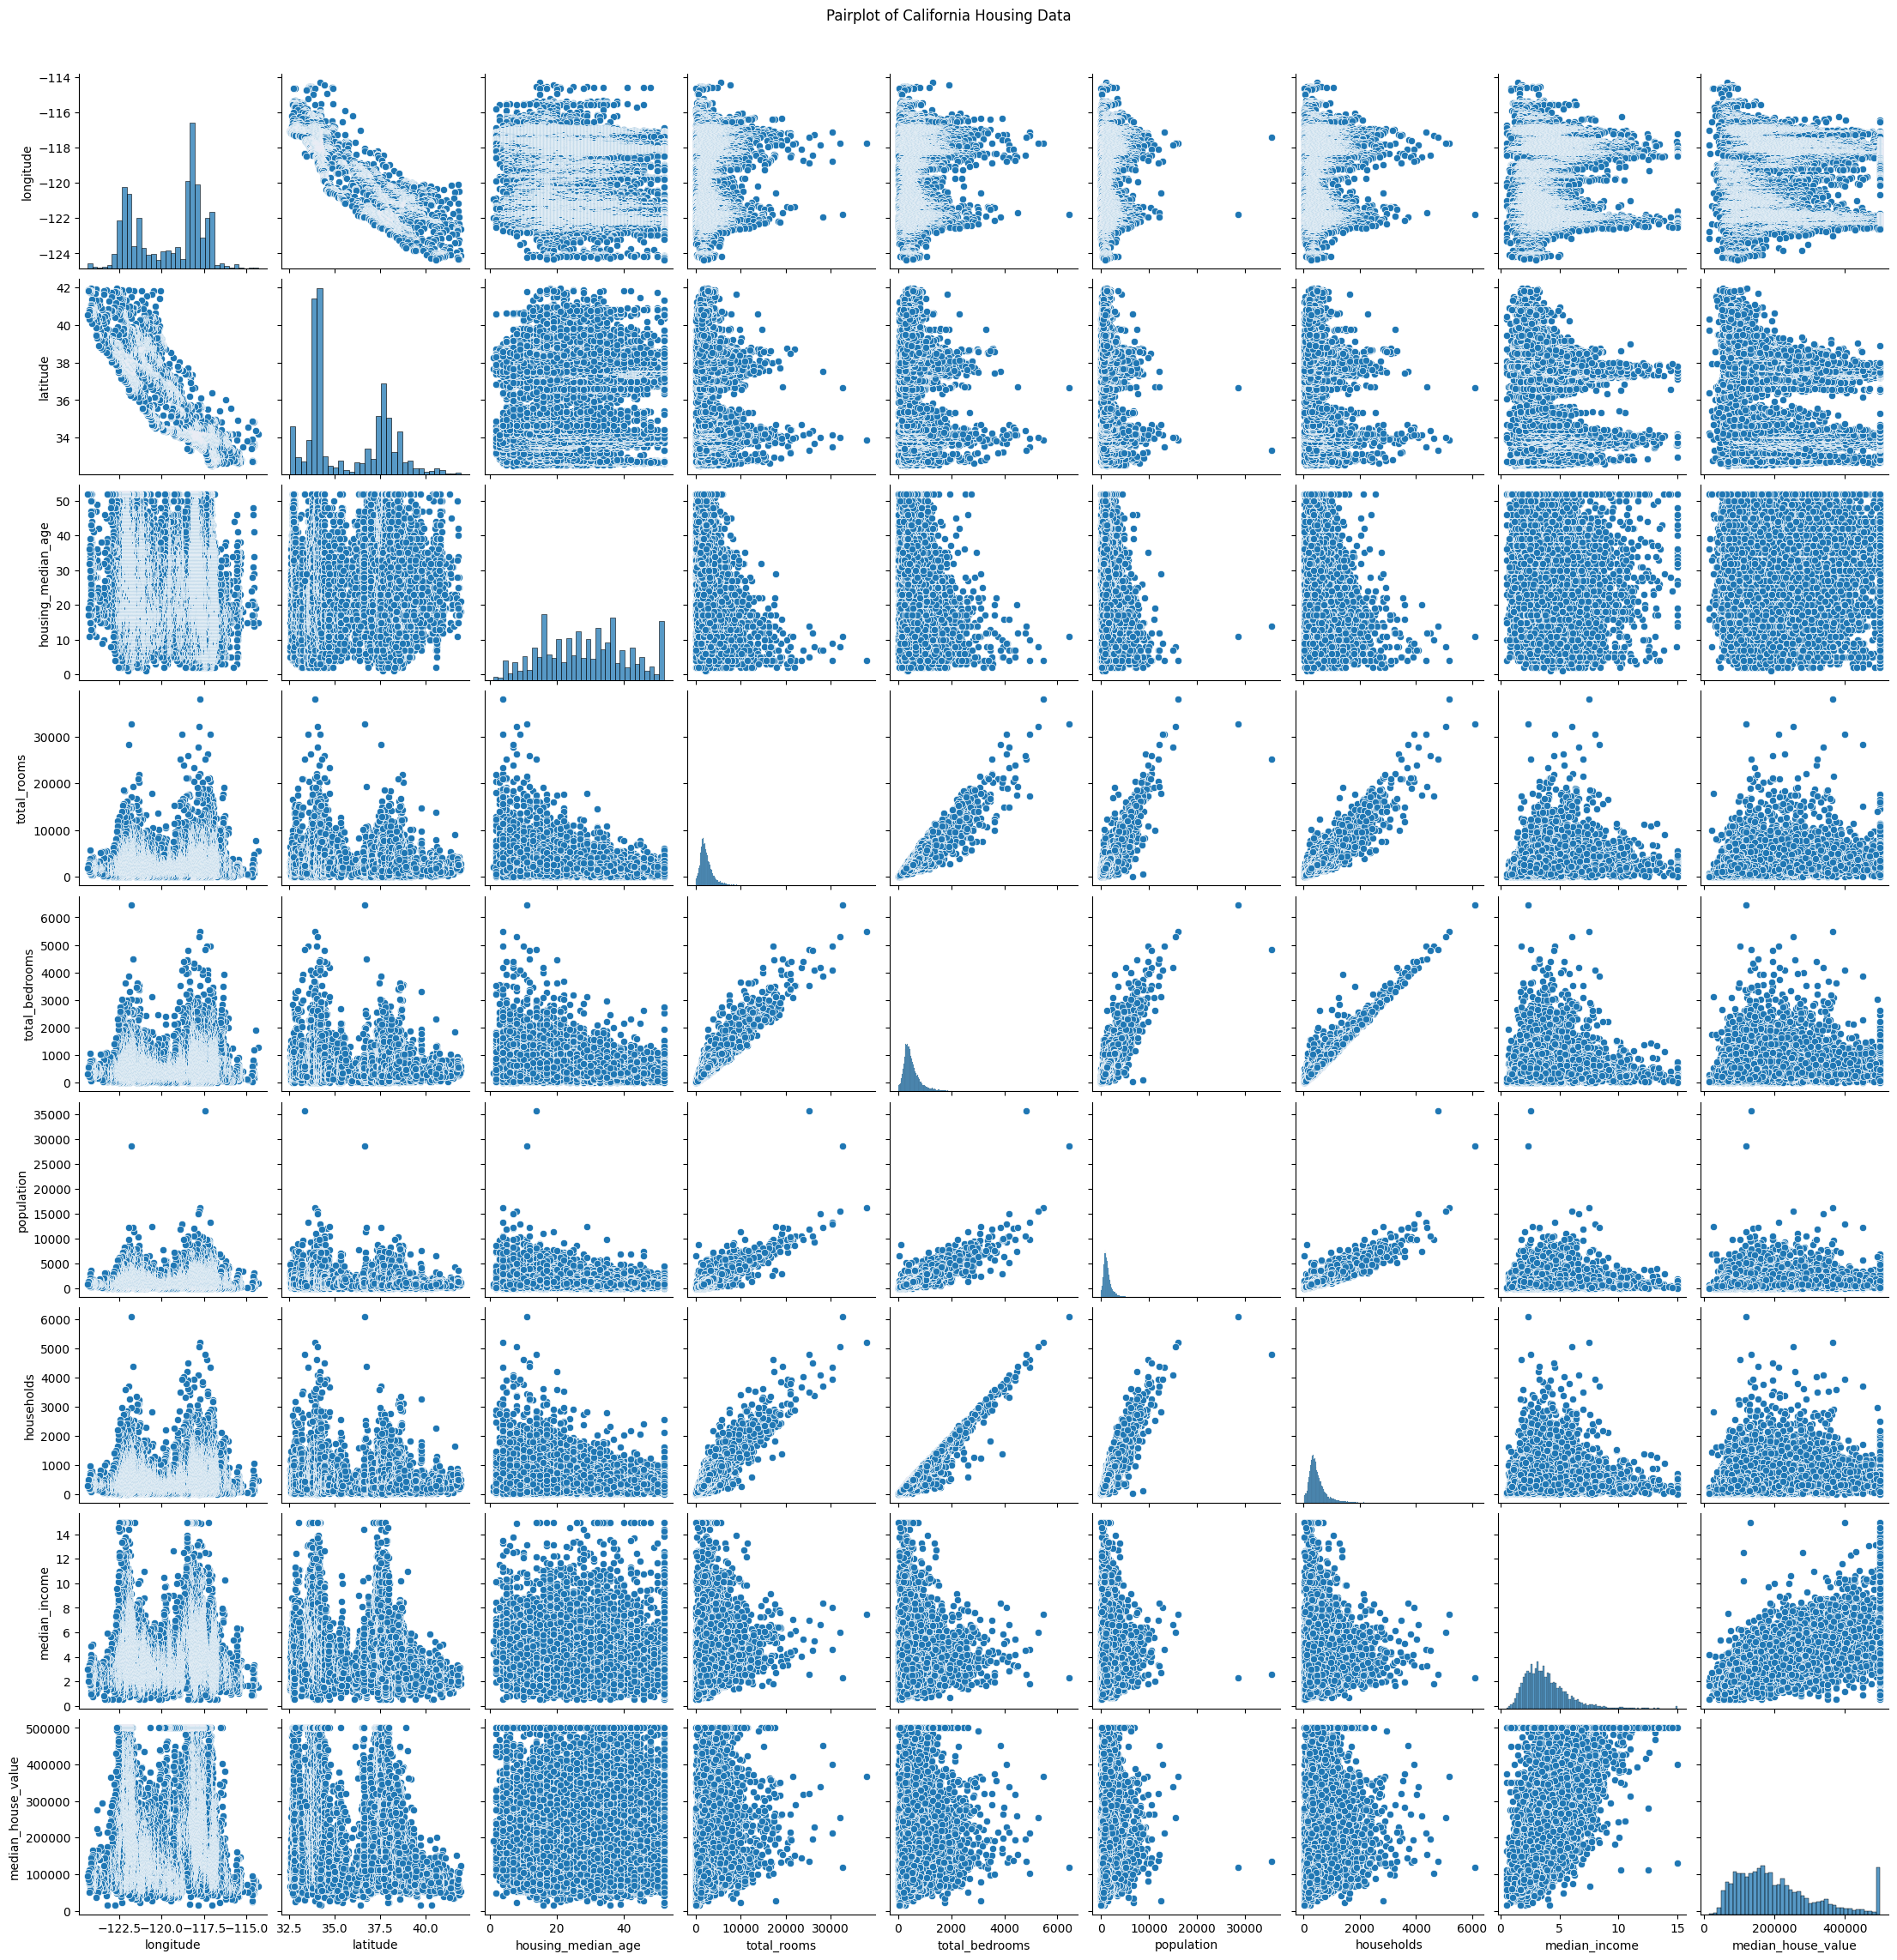

In [6]:
plt.figure(figsize=(15, 15))
sns.pairplot(df)
plt.suptitle('Pairplot of California Housing Data', y=1.02)
plt.show()

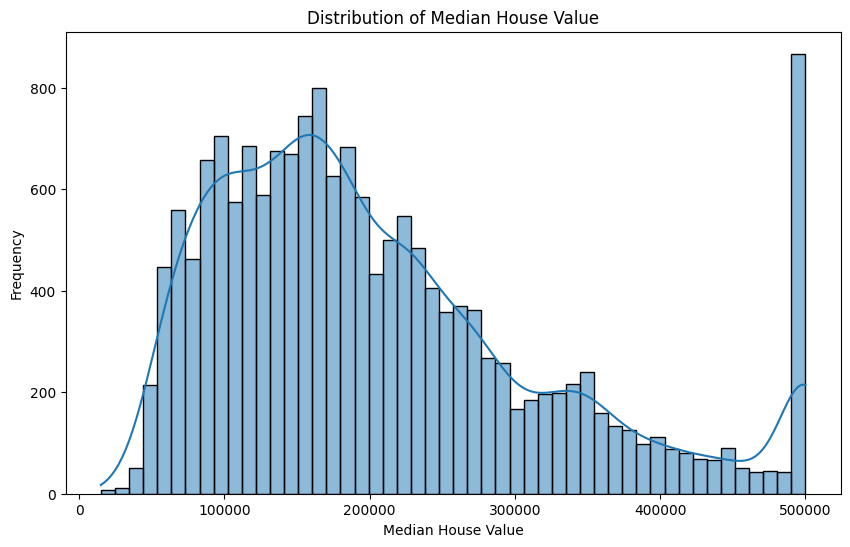

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

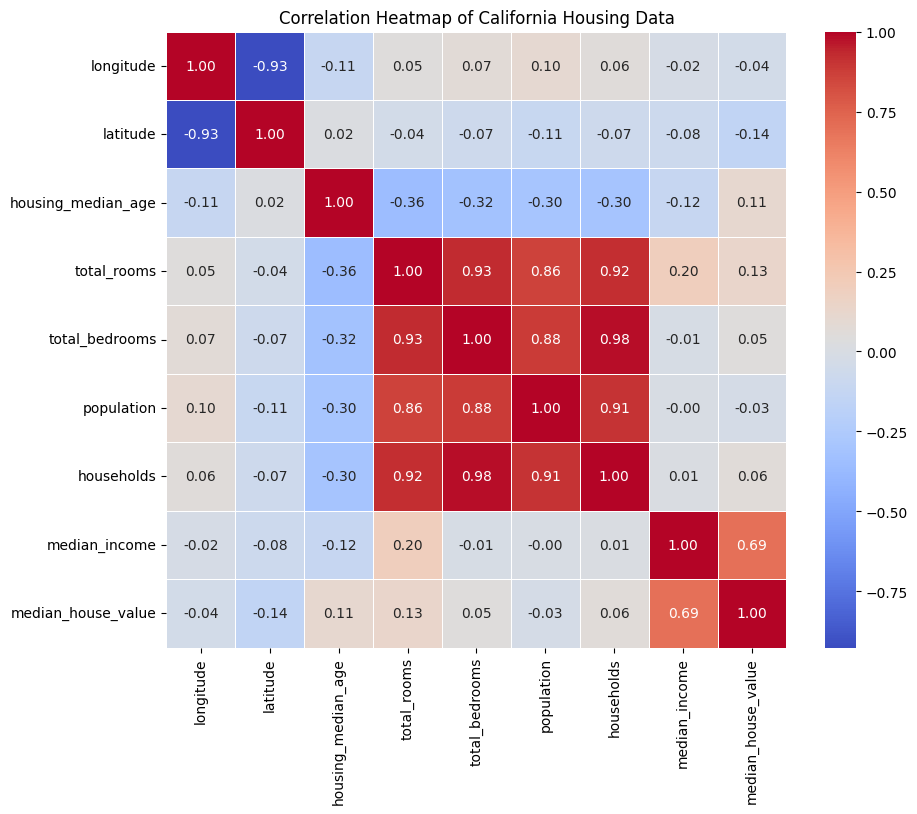

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of California Housing Data')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

First, we need to separate our features (X) from our target variable (y). In this case, `median_house_value` is our target.

In [33]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

Now, we'll split the data into training and testing sets. We'll use a 70-30 split, with `random_state=101` for reproducibility.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Next, we'll initialize and train the Linear Regression model.

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Model Evaluation
Now, let's evaluate the performance of our trained Linear Regression model on the test set.

In [38]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Mean Squared Error (MSE): 4691283870.38
R-squared (R2): 0.65


### Visualizing Predictions vs. Actuals
Let's visualize the relationship between the actual `y_test` values and the predicted `y_pred` values using a scatter plot. This helps in understanding how well the model's predictions align with the true values.

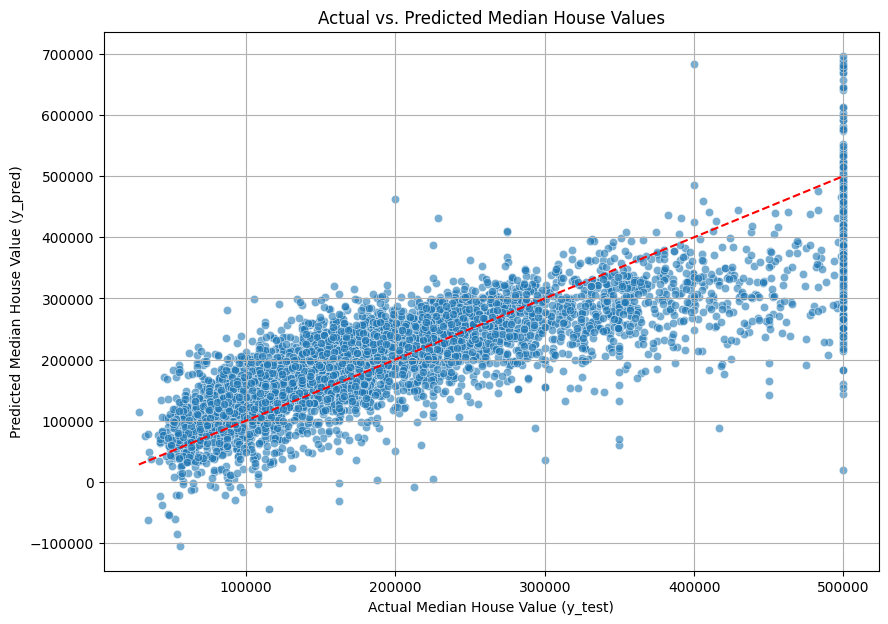

In [39]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Median House Value (y_test)')
plt.ylabel('Predicted Median House Value (y_pred)')
plt.title('Actual vs. Predicted Median House Values')
plt.grid(True)
plt.show()

### Feature Importance using Model Coefficients
For Linear Regression, the magnitude of the coefficients can indicate the importance of each feature in predicting the target variable. A larger absolute coefficient value suggests a stronger influence.

In [41]:
# Get the coefficients and feature names
coefficients = model.coef_
feature_names = X.columns

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to see the most important features
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

display(coef_df)

,Feature,Coefficient
0,longitude,-44068.543083
1,latitude,-43808.916940
7,median_income,40406.800077
2,housing_median_age,1124.767261
4,total_bedrooms,119.353510
6,households,43.660297
5,population,-36.317200
3,total_rooms,-9.497395


### Residual Scatter Plot
A residual plot is a graph that shows the residuals on the vertical axis and the independent variable (or in this case, the predicted values) on the horizontal axis. If the points in a residual plot are randomly dispersed around the horizontal axis, a linear regression model is appropriate for the data; otherwise, a non-linear model is more appropriate.

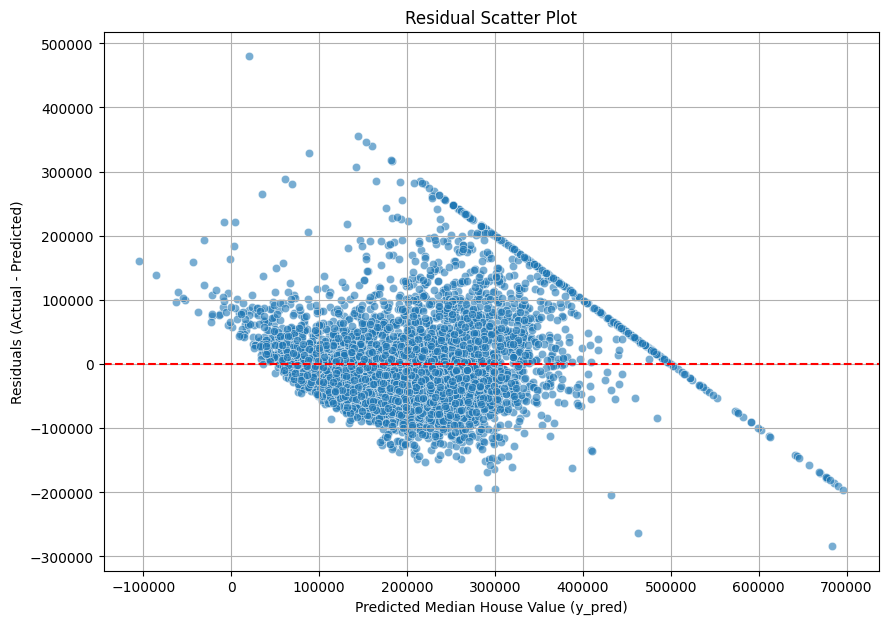

In [42]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Median House Value (y_pred)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Scatter Plot')
plt.grid(True)
plt.show()

### Histogram of Residuals with KDE
To further assess the model's assumptions, specifically the normality of residuals, we can plot a histogram of the residuals with a Kernel Density Estimate (KDE). Ideally, residuals should be normally distributed around zero.

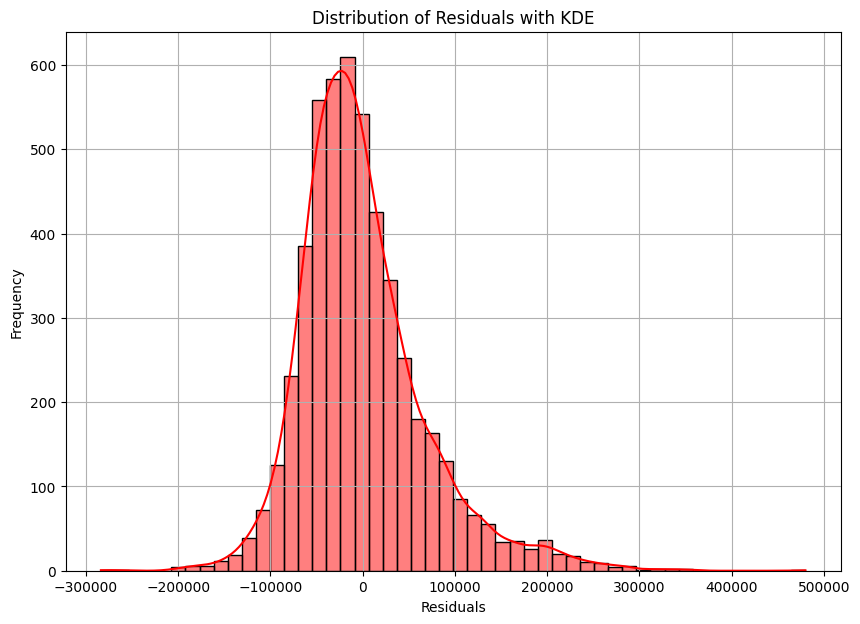

In [43]:
plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True, bins=50, color='red')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals with KDE')
plt.grid(True)
plt.show()

### Save the Trained Model

It's good practice to save your trained model so you can reuse it later without retraining. We'll use `joblib` for this purpose.

In [44]:
import joblib

# Define the filename for the model
model_filename = 'linear_regression_model.joblib'

# Save the model to disk
joblib.dump(model, model_filename)

print(f"Model saved successfully as '{model_filename}'")

Model saved successfully as 'linear_regression_model.joblib'
